# Computer Vision Assignment — Pose Estimation & Activity Classification
## Squat vs Standing Detection using MediaPipe Tasks API
**Video:** `https://youtube.com/shorts/-5LhNSMBrEs?si=OtTS20n5fNkP-Jyz `

**Model:** MediaPipe Pose Landmarker | **Activities:** Squat & Standing |



In [ ]:
!pip install mediapipe -q
!pip install opencv-python-headless matplotlib numpy -q

# Download the pose landmarker model (lite = fast, accurate enough)
!wget -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task -O pose_landmarker.task

import os
assert os.path.getsize('pose_landmarker.task') > 10000, "Model download failed — check internet"
print(f"Model size: {os.path.getsize('pose_landmarker.task') / 1e6:.1f} MB")
print("Done! → Runtime → Restart session")

In [1]:
from google.colab import files
uploaded = files.upload()
VIDEO_PATH = list(uploaded.keys())[0]
print(f" Video uploaded: {VIDEO_PATH}")


Saving exercise.mp4 to exercise.mp4
 Video uploaded: exercise.mp4


# Imports

In [2]:
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# New Tasks API — no mp.solutions needed, no protobuf conflict
import mediapipe as mp
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import PoseLandmarker, PoseLandmarkerOptions, RunningMode

print(f"MediaPipe : {mp.__version__}")
print(f"OpenCV    : {cv2.__version__}")
print(" All imports OK — no errors!")


MediaPipe : 0.10.35
OpenCV    : 4.13.0
 All imports OK — no errors!


In [3]:
# Video properties
cap   = cv2.VideoCapture(VIDEO_PATH)
FPS   = cap.get(cv2.CAP_PROP_FPS)
W     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
TOTAL = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()
print(f"Video → {W}×{H}  |  {FPS:.0f} fps  |  {TOTAL} frames  |  {TOTAL/FPS:.1f} s")

Video → 720×1280  |  30 fps  |  259 frames  |  8.6 s


## Task 1  Pose Detection & Pre-processing
- MediaPipe Pose Landmarker extracts 33 body keypoints per frame
- 5-frame rolling-mean smoothing applied to reduce jitter
- Skeleton overlay visualised on sample frames


In [4]:
# Extract keypoints using Tasks API (works with any protobuf)
options = PoseLandmarkerOptions(
    base_options=mp.tasks.BaseOptions(model_asset_path='pose_landmarker.task'),
    running_mode=RunningMode.IMAGE,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

frames_data   = []
sample_frames = {}
cap = cv2.VideoCapture(VIDEO_PATH)
idx = 0

with PoseLandmarker.create_from_options(options) as detector:
    while True:
        ret, frame = cap.read()
        if not ret: break

        rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result = detector.detect(mp_img)
        det    = len(result.pose_landmarks) > 0

        lm = {}
        if det:
            for i, l in enumerate(result.pose_landmarks[0]):
                lm[i] = dict(x=l.x, y=l.y, z=l.z, vis=l.visibility)

        frames_data.append(dict(frame=idx, detected=det, landmarks=lm))

        step = max(1, TOTAL // 5)
        if idx % step == 0 and len(sample_frames) < 5:
            sample_frames[idx] = frame.copy()
        idx += 1

cap.release()
TOTAL = len(frames_data)
det_n = sum(1 for f in frames_data if f['detected'])
print(f"Detected in {det_n}/{TOTAL} frames ({det_n/TOTAL*100:.1f}%)")


Detected in 254/254 frames (100.0%)


In [5]:
# Smoothing filter — 5-frame rolling mean
def smooth_landmarks(frames, window=5):
    all_ids = set()
    for f in frames:
        all_ids.update(f['landmarks'].keys())
    for lid in all_ids:
        xs = [f['landmarks'].get(lid, {}).get('x') for f in frames]
        ys = [f['landmarks'].get(lid, {}).get('y') for f in frames]
        def roll(arr):
            out = []
            for i in range(len(arr)):
                v = [arr[j] for j in range(max(0,i-window), min(len(arr),i+window+1)) if arr[j] is not None]
                out.append(float(np.mean(v)) if v else None)
            return out
        sx, sy = roll(xs), roll(ys)
        for i, f in enumerate(frames):
            if lid in f['landmarks'] and sx[i] is not None:
                f['landmarks'][lid]['x'] = sx[i]
                f['landmarks'][lid]['y'] = sy[i]
    return frames

frames_data = smooth_landmarks(frames_data, window=5)
print("Smoothing applied (window = 5 frames)")


Smoothing applied (window = 5 frames)


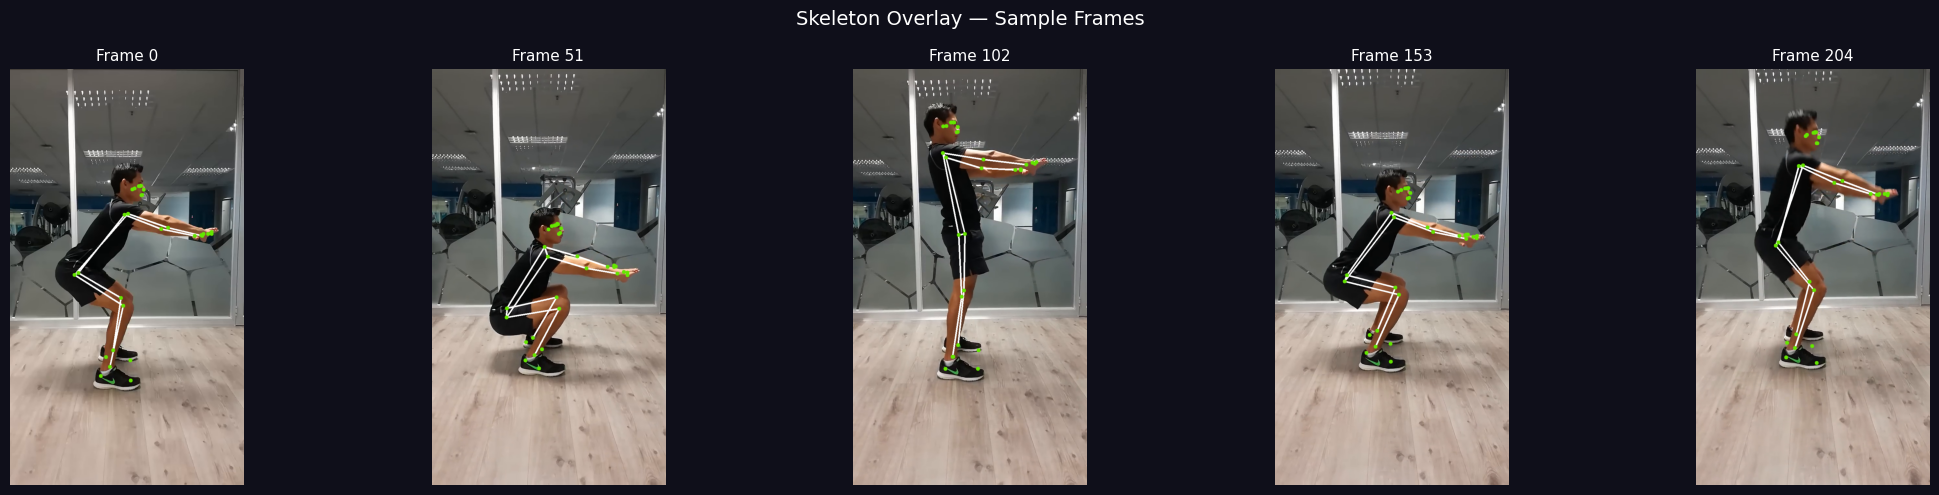

 Saved → skeleton_overlay.png


In [6]:
# Draw skeleton overlay on sample frames using Tasks API
def draw_skeleton(frame_bgr, lm_dict, W, H):
    img = frame_bgr.copy()
    CONNECTIONS = [
        (11,12),(11,13),(13,15),(12,14),(14,16),
        (11,23),(12,24),(23,24),(23,25),(24,26),(25,27),(26,28)
    ]
    pts = {}
    for lid, d in lm_dict.items():
        pts[lid] = (int(d['x']*W), int(d['y']*H))
    for a,b in CONNECTIONS:
        if a in pts and b in pts:
            cv2.line(img, pts[a], pts[b], (255,255,255), 3)
    for lid, pt in pts.items():
        cv2.circle(img, pt, 6, (0,230,100), -1)
    return img

options_img = PoseLandmarkerOptions(
    base_options=mp.tasks.BaseOptions(model_asset_path='pose_landmarker.task'),
    running_mode=RunningMode.IMAGE
)
keys = sorted(sample_frames.keys())
fig, axes = plt.subplots(1, len(keys), figsize=(22,5))
fig.patch.set_facecolor('#0f0f1a')

with PoseLandmarker.create_from_options(options_img) as det2:
    for ax, fi in zip(axes, keys):
        bgr = sample_frames[fi]
        lm  = frames_data[fi]['landmarks']
        vis = draw_skeleton(bgr, lm, W, H)
        ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        ax.set_title(f"Frame {fi}", color='white', fontsize=11)
        ax.axis('off')

fig.suptitle("Skeleton Overlay — Sample Frames", color='white', fontsize=14)
plt.tight_layout()
plt.savefig("skeleton_overlay.png", dpi=120, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(" Saved → skeleton_overlay.png")

## Task 2 — Joint Angle Computation & Tracking


In [8]:
def get_pt(lm, idx):
    if idx in lm:
        return np.array([lm[idx]['x'], lm[idx]['y']])
    return None

def angle_3pts(a, b, c):
    """Angle in degrees at vertex b."""
    ba = a - b
    bc = c - b
    cos_v = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    return math.degrees(math.acos(np.clip(cos_v, -1.0, 1.0)))

def smooth_arr(arr, w=5):
    out = []
    for i in range(len(arr)):
        v = [arr[j] for j in range(max(0, i-w), min(len(arr), i+w+1)) if arr[j] is not None]
        out.append(float(np.mean(v)) if v else None)
    return out

knee_raw = []; hip_raw = []; shoulder_raw = []
for f in frames_data:
    lm = f['landmarks']
    ka = ha = sa = None
    if f['detected']:
        rh = get_pt(lm, 24); rk = get_pt(lm, 26); ra = get_pt(lm, 28)
        rs = get_pt(lm, 12); re = get_pt(lm, 14)
        if all(x is not None for x in [rh, rk, ra]):
            ka = angle_3pts(rh, rk, ra)
        if all(x is not None for x in [rs, rh, rk]):
            ha = angle_3pts(rs, rh, rk)
        if all(x is not None for x in [re, rs, rh]):
            sa = angle_3pts(re, rs, rh)
    knee_raw.append(ka); hip_raw.append(ha); shoulder_raw.append(sa)

knee     = smooth_arr(knee_raw)
hip      = smooth_arr(hip_raw)
shoulder = smooth_arr(shoulder_raw)

vk = [x for x in knee     if x is not None]
vh = [x for x in hip      if x is not None]
vs = [x for x in shoulder if x is not None]

print(f"Knee     → min {min(vk):.1f}°  max {max(vk):.1f}°  mean {np.mean(vk):.1f}°")
print(f"Hip      → min {min(vh):.1f}°  max {max(vh):.1f}°  mean {np.mean(vh):.1f}°")
print(f"Shoulder → min {min(vs):.1f}°  max {max(vs):.1f}°  mean {np.mean(vs):.1f}°")
print(" Angles computed")

Knee     → min 41.9°  max 159.6°  mean 96.4°
Hip      → min 34.3°  max 174.1°  mean 92.6°
Shoulder → min 62.3°  max 136.1°  mean 108.6°
 Angles computed


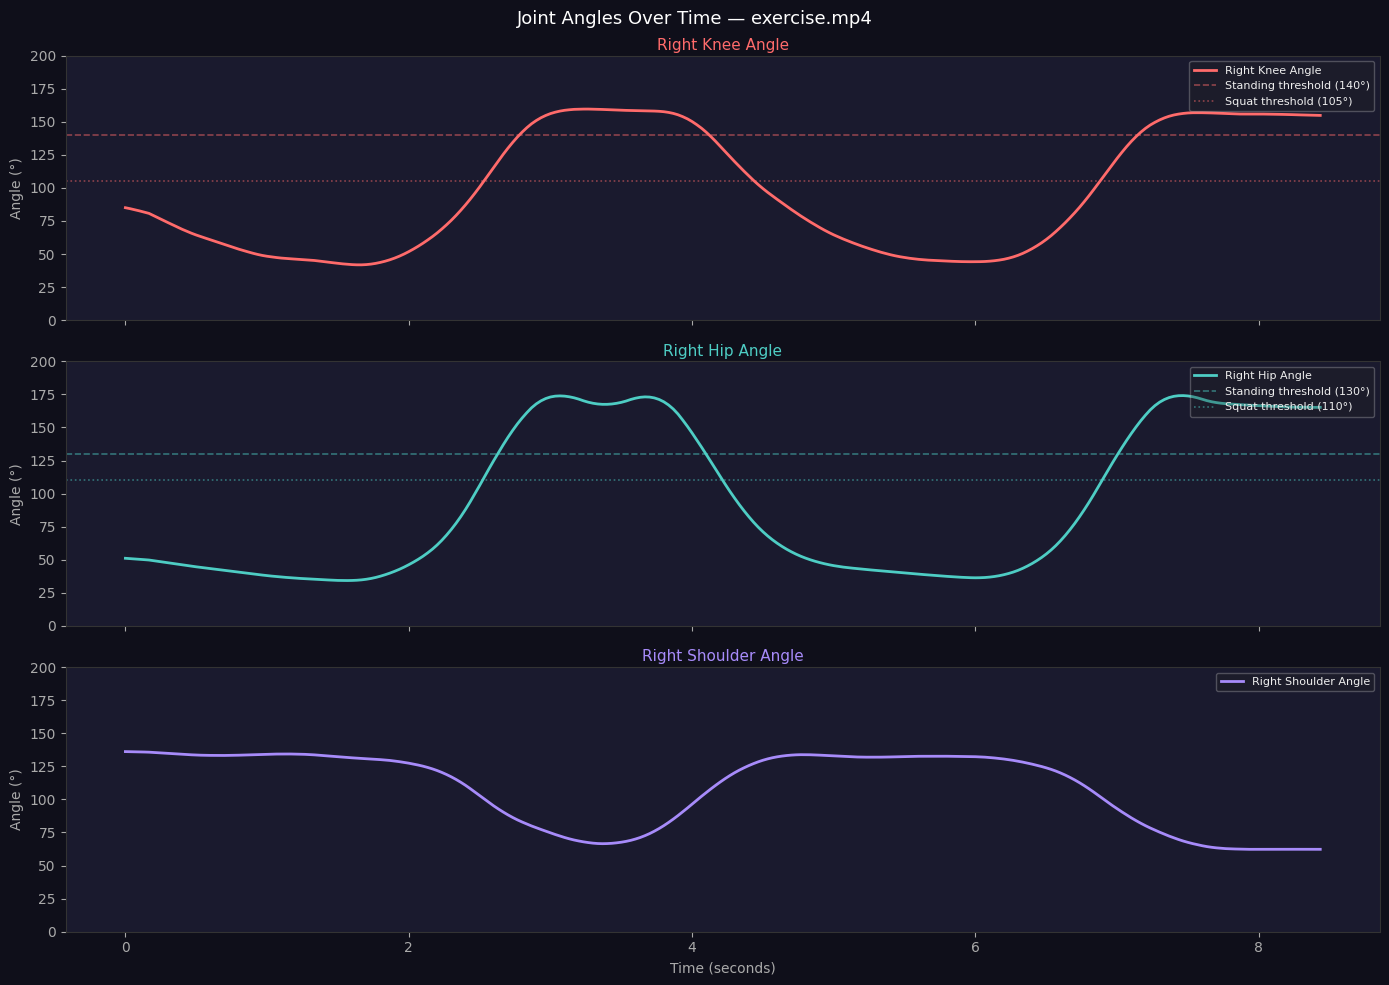

 Saved → plot_angles.png


In [9]:
# Plot angles over time
t=[i/FPS for i in range(TOTAL)]
fig,axes=plt.subplots(3,1,figsize=(14,10),sharex=True)
fig.patch.set_facecolor('#0f0f1a')
cfg=[(knee,'#FF6B6B','Right Knee Angle',140,105),
     (hip,'#4ECDC4','Right Hip Angle',130,110),
     (shoulder,'#A78BFA','Right Shoulder Angle',None,None)]
for ax,(arr,col,title,hi,lo) in zip(axes,cfg):
    ax.set_facecolor('#1a1a2e')
    for sp in ax.spines.values(): sp.set_color('#333')
    ax.tick_params(colors='#aaa')
    vals=[v if v else np.nan for v in arr]
    ax.plot(t,vals,color=col,linewidth=2,label=title)
    if hi: ax.axhline(hi,color=col,linestyle='--',alpha=0.5,linewidth=1.2,label=f'Standing threshold ({hi}°)')
    if lo: ax.axhline(lo,color=col,linestyle=':',alpha=0.5,linewidth=1.2,label=f'Squat threshold ({lo}°)')
    ax.set_ylabel('Angle (°)',color='#aaa'); ax.set_ylim(0,200)
    ax.set_title(title,color=col,fontsize=11,pad=4)
    ax.legend(loc='upper right',fontsize=8,framealpha=0.3,labelcolor='#eee',facecolor='#222')
axes[-1].set_xlabel('Time (seconds)',color='#aaa')
fig.suptitle('Joint Angles Over Time — exercise.mp4',color='white',fontsize=13)
plt.tight_layout()
plt.savefig('plot_angles.png',dpi=150,bbox_inches='tight',facecolor='#0f0f1a')
plt.show()
print(" Saved → plot_angles.png")

# Task 3 — Rule-Based Activity Classification
```
Standing   →  knee_angle > 140°  AND  hip_angle > 130°
Squat      →  knee_angle < 105°  AND  hip_angle < 110°
Transition →  everything in between
```


In [10]:
def classify(ka, ha):
    if ka is None or ha is None: return "Unknown"
    if ka > 140 and ha > 130:   return "Standing"
    if ka < 105 and ha < 110:   return "Squat"
    return "Transition"

predictions=[classify(knee[i],hip[i]) for i in range(TOTAL)]
print("Predicted distribution:")
for act,cnt in sorted(Counter(predictions).items()):
    print(f"  {act:<12} {cnt:4d} frames  {cnt/TOTAL*100:5.1f}%  {'█'*int(cnt/TOTAL*40)}")


Predicted distribution:
  Squat         149 frames   58.7%  ███████████████████████
  Standing       78 frames   30.7%  ████████████
  Transition     27 frames   10.6%  ████


In [12]:
# Ground truth —
SQUAT_RANGES = [(0,65),(136,210)]
ground_truth=[]
for i in range(TOTAL):
    label="Standing"
    for s,e in SQUAT_RANGES:
        if s<=i<=e: label="Squat"; break
    ground_truth.append(label)

correct=evaluated=0
for i in range(TOTAL):
    if predictions[i]=="Transition": continue
    evaluated+=1
    if predictions[i]==ground_truth[i]: correct+=1
accuracy=correct/evaluated*100 if evaluated else 0
print("="*50)
print(f"  Accuracy        : {accuracy:.1f}%")
print(f"  Correct frames  : {correct} / {evaluated}")
print(f"  Transitions skip: {TOTAL-evaluated}")
print("="*50)


  Accuracy        : 94.7%
  Correct frames  : 215 / 227
  Transitions skip: 27
